# Benchmark Comparison
Calculate UVLF using the standard method (Finkelstein et al. 2023)

In [1]:
import numpy as np 
from tqdm import tqdm

In [2]:
import pickle

In [3]:
from astropy.cosmology import Planck18

In [4]:
from px2cosmo import fm as FM
from px2cosmo import util as UT

In [5]:
import corner as DFM
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

In [6]:
omega_true = np.load("/Users/ch54662/data/px2cosmo/mock/omega_true.npy")
X_obs_z14 = np.load("/Users/ch54662/data/px2cosmo/mock/X_obs_z14.npy")
X_obs_z11 = np.load("/Users/ch54662/data/px2cosmo/mock/X_obs_z11.npy")
X_obs_z9 = np.load("/Users/ch54662/data/px2cosmo/mock/X_obs_z9.npy")

## median redshift

In [7]:
def get_median_redshift(X_obs, Nmc=10): 
    ''' get median redshift by stacking the redshift posteriors
    '''
    z_med = X_obs[:,0] # median redshift
    sig_z = X_obs[:,2] # 1sigma redshift

    _zs = []
    for _ in range(Nmc): 
        _zs.append(z_med + sig_z * np.random.normal(size=len(z_med)))
    return np.median(_zs)

In [8]:
print('median z for z~14 sample', get_median_redshift(X_obs_z14, Nmc=100))
print('median z for z~11 sample', get_median_redshift(X_obs_z11, Nmc=100))
print('median z for z~9 sample', get_median_redshift(X_obs_z9, Nmc=100))

median z for z~14 sample 13.936223565402818
median z for z~11 sample 10.519674682495248
median z for z~9 sample 8.537231672249376


In [9]:
z_meds = [get_median_redshift(X_obs_z9, Nmc=100), get_median_redshift(X_obs_z11, Nmc=100), get_median_redshift(X_obs_z14, Nmc=100)]

## effective volume calculation

In [10]:
def P_select(mock, name='mock0'): 
    ''' impose selection function 
    '''
    if name == 'z14': 
        prob_z = np.exp(-(mock[:,0] - 14.0)**2)

        # convert mock absolute magnitude to apparent magnitudes
        dl = FM.dl_spline(mock[:,0])
        mock_muv = mock[:,1] + 5 * np.log10(dl / 10.) 

        # m_uv selection weights
        w_muv_select = FM._select_muv(mock_muv, c_erf0=1., c_erf1=32)
    
    elif name == 'z9': 
        prob_z = np.exp(-(mock[:,0] - 9.0)**2)

        # convert mock absolute magnitude to apparent magnitudes
        dl = FM.dl_spline(mock[:,0])
        mock_muv = mock[:,1] + 5 * np.log10(dl / 10.) 

        # m_uv selection weights
        w_muv_select = FM._select_muv(mock_muv, c_erf0=1., c_erf1=32)

    elif name == 'z11': 
        prob_z = np.exp(-(mock[:,0] - 11.0)**2)
        
        # convert mock absolute magnitude to apparent magnitudes
        dl = FM.dl_spline(mock[:,0])
        mock_muv = mock[:,1] + 5 * np.log10(dl / 10.) 

        # m_uv selection weights
        w_muv_select = FM._select_muv(mock_muv, c_erf0=1., c_erf1=32)

    return prob_z * w_muv_select
    

def Veff(Muv, sample='z11'): 
    ''' calculate effective volume given Muv and sample
    '''
    # completeness 
    C_Muv_z = P_select(np.vstack([FM.zlist, np.tile(Muv, (FM.Nz,))]).T, name=sample)
    
    return np.sum(C_Muv_z * FM.DeltaVlist)

# $V_{\rm final}$ with MC

In [11]:
Muv_bin = np.linspace(-14, -22, 17)

In [12]:
def MC_Vfinal(X_obs, sample='z11'): 
    # draw from Muv posterio
    Muv_mc = X_obs[:,1] + X_obs[:,3] * np.random.normal(size=X_obs.shape[0])

    # effective volume for Muv_mc
    _Veff = np.array([Veff(_Muv, sample=sample) for _Muv in Muv_mc])
    
    ibin = np.digitize(Muv_mc, Muv_bin) - 1
    
    Vfinal = np.zeros(16)
    Nbin = np.zeros(16).astype(int)
    for i in range(16): 
        is_bin = (ibin == i)
        if np.sum(is_bin) == 0: continue
        Vfinal[i] = np.mean(_Veff[is_bin])
        Nbin[i] = np.sum(is_bin)
    return Vfinal, Nbin

```
uvlf = np.zeros((Muv_bin.shape[0]-1, 9))
nbins = [] 
for i, z in enumerate([9., 11., 14.]): 
    LFs = [] 
    for _ in range(200): 
        Vf, Nb = MC_Vfinal([X_obs_z9, X_obs_z11, X_obs_z14][i], sample='z%i' % int(z))
        LFs.append(Nb/Vf/0.5)
    LFs = np.array(LFs)

    nbin, q0, q1, q2 = np.zeros(LFs.shape[1]), np.zeros(LFs.shape[1]), np.zeros(LFs.shape[1]), np.zeros(LFs.shape[1])
    for ii in range(LFs.shape[1]): 
        nbin[ii] = np.sum(~np.isnan(LFs[:,ii]))
        if (np.sum(~np.isnan(LFs[:,ii])) < 150): continue
        _q0, _q1, _q2 = np.nanquantile(LFs[:,ii], [0.16, 0.5, 0.84])
        q0[ii] = _q0
        q1[ii] = _q1
        q2[ii] = _q2
                
    uvlf[:,i*3] = q1
    uvlf[:,i*3+1] = q1-q0
    uvlf[:,i*3+2] = q2-q1
    nbins.append(nbin)
np.savetxt('/Users/ch54662/data/px2cosmo/mock/benchmark/uvlf_benchmark.dat', uvlf, header=f'UVLF {z_meds[0]} median, 16th, 84th, {z_meds[1]} median, 16th, 84th, {z_meds[2]} meidan, 16th, 84th')    
```

In [13]:
uvlf = np.loadtxt('/Users/ch54662/data/px2cosmo/mock/benchmark/uvlf_benchmark.dat', skiprows=1)

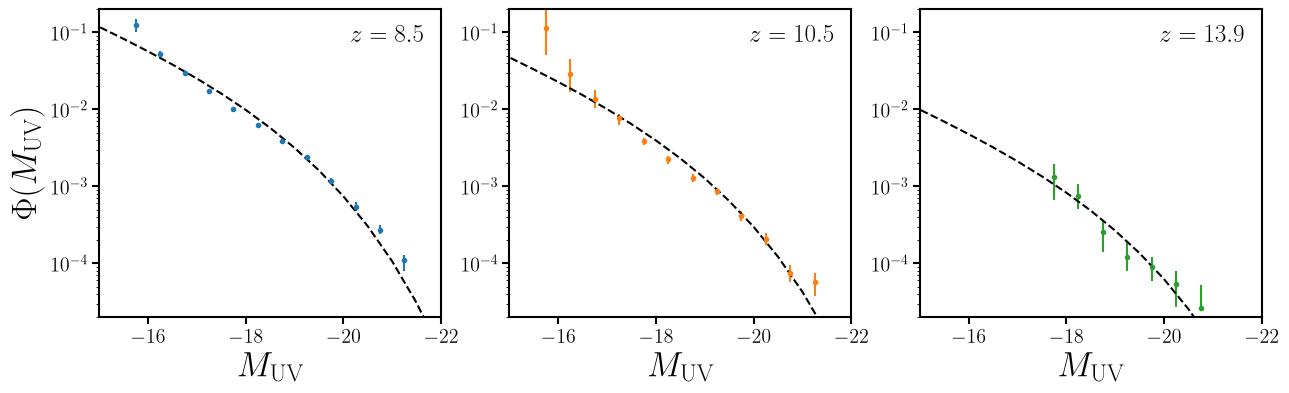

In [14]:
fig = plt.figure(figsize=(15,4))
for i, z in enumerate(z_meds): 
    sub = fig.add_subplot(1,3,i+1)
    sub.errorbar(0.5 * (Muv_bin[:-1] + Muv_bin[1:]), uvlf[:,i*3], yerr=[uvlf[:,i*3+1], uvlf[:,i*3+2]], fmt='.C%i' % i)
    sub.plot(Muv_bin, omega_true[-1] * UT.LF(Muv_bin, z, omega_true[:-1]), c='k', ls='--')
    sub.text(0.95, 0.95, r'$z=%.1f$' % z, fontsize=18, transform=sub.transAxes, ha='right', va='top')
    sub.set_xlabel(r'$M_{\rm UV}$', fontsize=25)
    sub.set_xlim(-15, -22)
    if i == 0: sub.set_ylabel(r'$\Phi(M_{\rm UV})$', fontsize=25)
    else: sub.set_yticklabels([])
    sub.set_yscale('log') 
    sub.set_ylim(2e-5, 2e-1)

# emcee fit to schechter function 

In [15]:
import emcee

In [16]:
prior_bounds = [[-2., -1.2], 
                [-2., -1.2], 
                [-0.6, 0.2], 
                [-22., -16], 
                [5e-4, 5e-2]]

In [17]:
def log_prior(omega): 
    alpha, beta, gamma, Muv_s, phi_amp = omega
    if (prior_bounds[0][0] < alpha < prior_bounds[0][1] and 
        prior_bounds[1][0] < beta < prior_bounds[1][1] and 
        prior_bounds[2][0] < gamma < prior_bounds[2][1] and 
        prior_bounds[3][0] < Muv_s < prior_bounds[3][1] and 
        prior_bounds[4][0] < phi_amp < prior_bounds[4][1]): 
        return 0.
    return -np.inf

In [18]:
z14_bins = (uvlf[:,6] > 0)
def log_posterior_z14(omega, silent=True):
    lp = log_prior(omega) # prior 
    if not np.isfinite(lp): return -np.inf
            
    # LF double power law
    lf_model = omega[-1] * UT.LF(0.5*(Muv_bin[:-1]+Muv_bin[1:]), z_meds[2], omega[:-1])
    # chi2
    chi2 = np.sum(((lf_model - uvlf[:,6])**2 / (0.5 * (uvlf[:,7]+uvlf[:,8]))**2)[z14_bins])
    return -0.5*chi2

In [19]:
ndim, nwalkers = 5, 20
p0 = np.array([
    np.random.uniform(prior_bounds[0][0], prior_bounds[0][1], nwalkers),
    np.random.uniform(prior_bounds[1][0], prior_bounds[1][1], nwalkers),
    np.random.uniform(prior_bounds[2][0], prior_bounds[2][1], nwalkers),
    np.random.uniform(prior_bounds[3][0], prior_bounds[3][1], nwalkers),
    np.random.uniform(prior_bounds[4][0], prior_bounds[4][1], nwalkers),
]).T

sampler_z14 = emcee.EnsembleSampler(nwalkers, ndim, log_posterior_z14)
_ = sampler_z14.run_mcmc(p0, 50000, progress=True)

/var/folders/y3/8t3m3rcs365c62spx46f98vm0000gq/T/ipykernel_16718/2439210916.py:9: RuntimeWarning: divide by zero encountered in divide
  chi2 = np.sum(((lf_model - uvlf[:,6])**2 / (0.5 * (uvlf[:,7]+uvlf[:,8]))**2)[z14_bins])
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50000/50000 [00:12<00:00, 3921.38it/s]


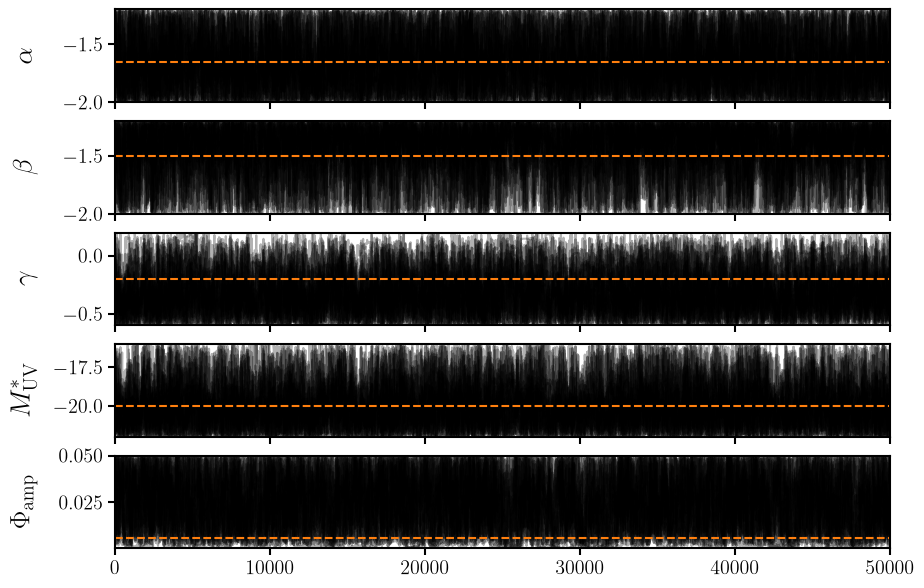

In [20]:
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
samples = sampler_z14.get_chain()
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.plot([0, samples.shape[0]], [omega_true[i], omega_true[i]], c='C1', ls='--')
    ax.set_xlim(0, len(samples))
    ax.set_ylabel([r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'][i], fontsize=20)
    ax.yaxis.set_label_coords(-0.1, 0.5)
    ax.set_ylim(prior_bounds[i])

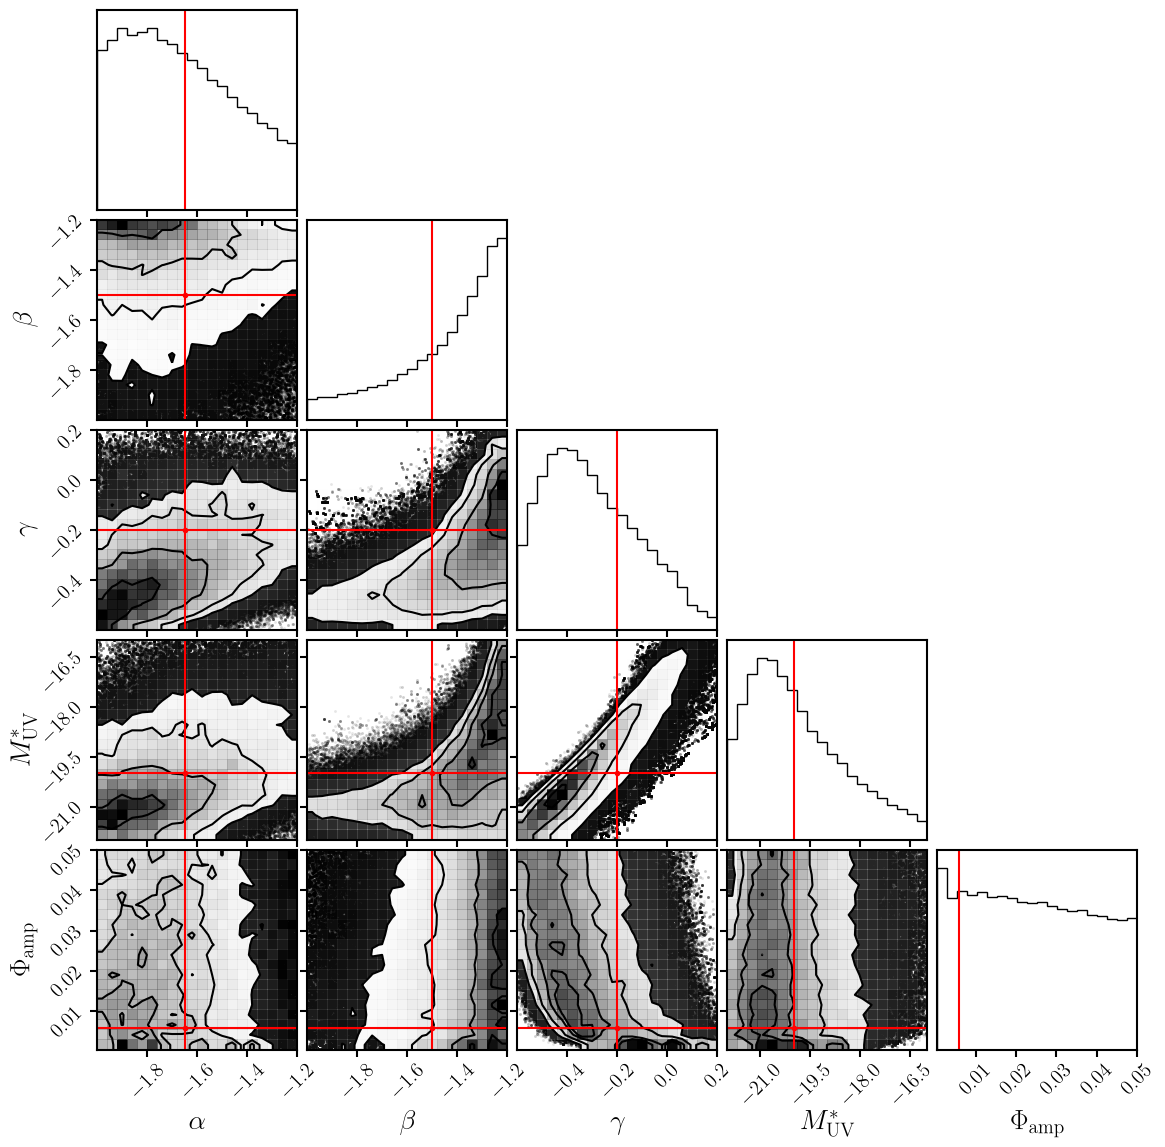

In [21]:
fig = DFM.corner(sampler_z14.flatchain[20000:,:], 
                 range=prior_bounds, 
                 labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'], label_kwargs={'fontsize': 20})
DFM.overplot_points(fig, [omega_true], color='red')
DFM.overplot_lines(fig, omega_true, color='red')

(2e-05, 0.2)

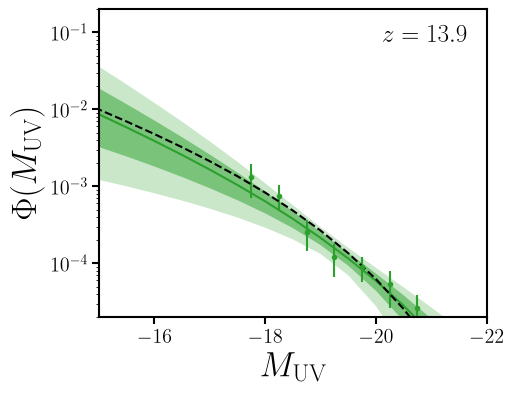

In [22]:
fig = plt.figure(figsize=(5,4))
sub = fig.add_subplot(111)
i = 2
LFs = [] 
for _om in sampler_z14.flatchain[20000:,:]: 
    LFs.append(_om[-1] * UT.LF(Muv_bin, z_meds[i], _om[:-1]))
q00, q0, q1, q2, q22 = np.quantile(np.array(LFs), [0.025, 0.16, 0.5, 0.84, 0.975], axis=0)

sub.fill_between(Muv_bin, q00, q22, edgecolor='none', facecolor='C%i' % i, alpha=0.25)
sub.fill_between(Muv_bin, q0, q2, edgecolor='none', facecolor='C%i' % i, alpha=0.5)
sub.plot(Muv_bin, q1, color='C%i' % i)
sub.errorbar(0.5*(Muv_bin[:-1]+Muv_bin[1:]), uvlf[:,6], yerr=0.5*(uvlf[:,7]+uvlf[:,8]), fmt='.C%i' % i)

sub.plot(Muv_bin, omega_true[-1] * UT.LF(Muv_bin, z_meds[i], omega_true[:-1]), c='k', ls='--')
sub.text(0.95, 0.95, r'$z=%.1f$' % z_meds[i], fontsize=18, transform=sub.transAxes, ha='right', va='top')
sub.set_xlabel(r'$M_{\rm UV}$', fontsize=25)
sub.set_xlim(-15, -22)
sub.set_ylabel(r'$\Phi(M_{\rm UV})$', fontsize=25)
sub.set_yscale('log') 
sub.set_ylim(2e-5, 2e-1)

In [23]:
z11_bins = (uvlf[:,3] > 0)
def log_posterior_z11(omega, silent=True):
    lp = log_prior(omega) # prior 
    if not np.isfinite(lp): return -np.inf
        
    # LF double power law
    lf_model = omega[-1] * UT.LF(0.5*(Muv_bin[:-1]+Muv_bin[1:]), z_meds[1], omega[:-1])
    # chi2
    chi2 = np.sum(((lf_model - uvlf[:,3])**2 / (0.5 * (uvlf[:,4]+uvlf[:,5]))**2)[z11_bins])
    return -0.5*chi2

In [24]:
ndim, nwalkers = 5, 20
p0 = np.array([
    np.random.uniform(prior_bounds[0][0], prior_bounds[0][1], nwalkers),
    np.random.uniform(prior_bounds[1][0], prior_bounds[1][1], nwalkers),
    np.random.uniform(prior_bounds[2][0], prior_bounds[2][1], nwalkers),
    np.random.uniform(prior_bounds[3][0], prior_bounds[3][1], nwalkers),
    np.random.uniform(prior_bounds[4][0], prior_bounds[4][1], nwalkers),
]).T

sampler_z11 = emcee.EnsembleSampler(nwalkers, ndim, log_posterior_z11)
_ = sampler_z11.run_mcmc(p0, 50000, progress=True)

/var/folders/y3/8t3m3rcs365c62spx46f98vm0000gq/T/ipykernel_16718/1087412485.py:9: RuntimeWarning: divide by zero encountered in divide
  chi2 = np.sum(((lf_model - uvlf[:,3])**2 / (0.5 * (uvlf[:,4]+uvlf[:,5]))**2)[z11_bins])
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50000/50000 [00:13<00:00, 3794.11it/s]


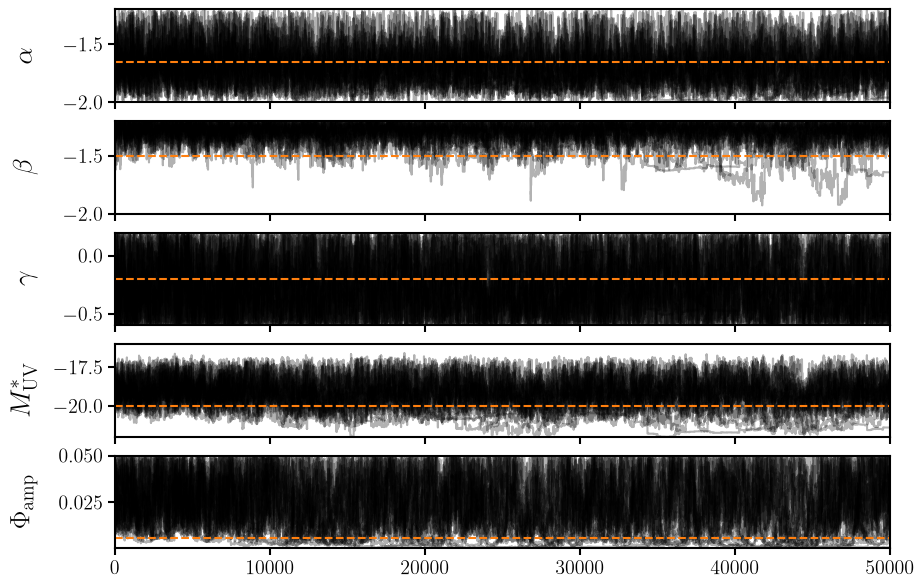

In [25]:
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
samples = sampler_z11.get_chain()
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.plot([0, samples.shape[0]], [omega_true[i], omega_true[i]], c='C1', ls='--')
    ax.set_xlim(0, len(samples))
    ax.set_ylabel([r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'][i], fontsize=20)
    ax.yaxis.set_label_coords(-0.1, 0.5)
    ax.set_ylim(prior_bounds[i])

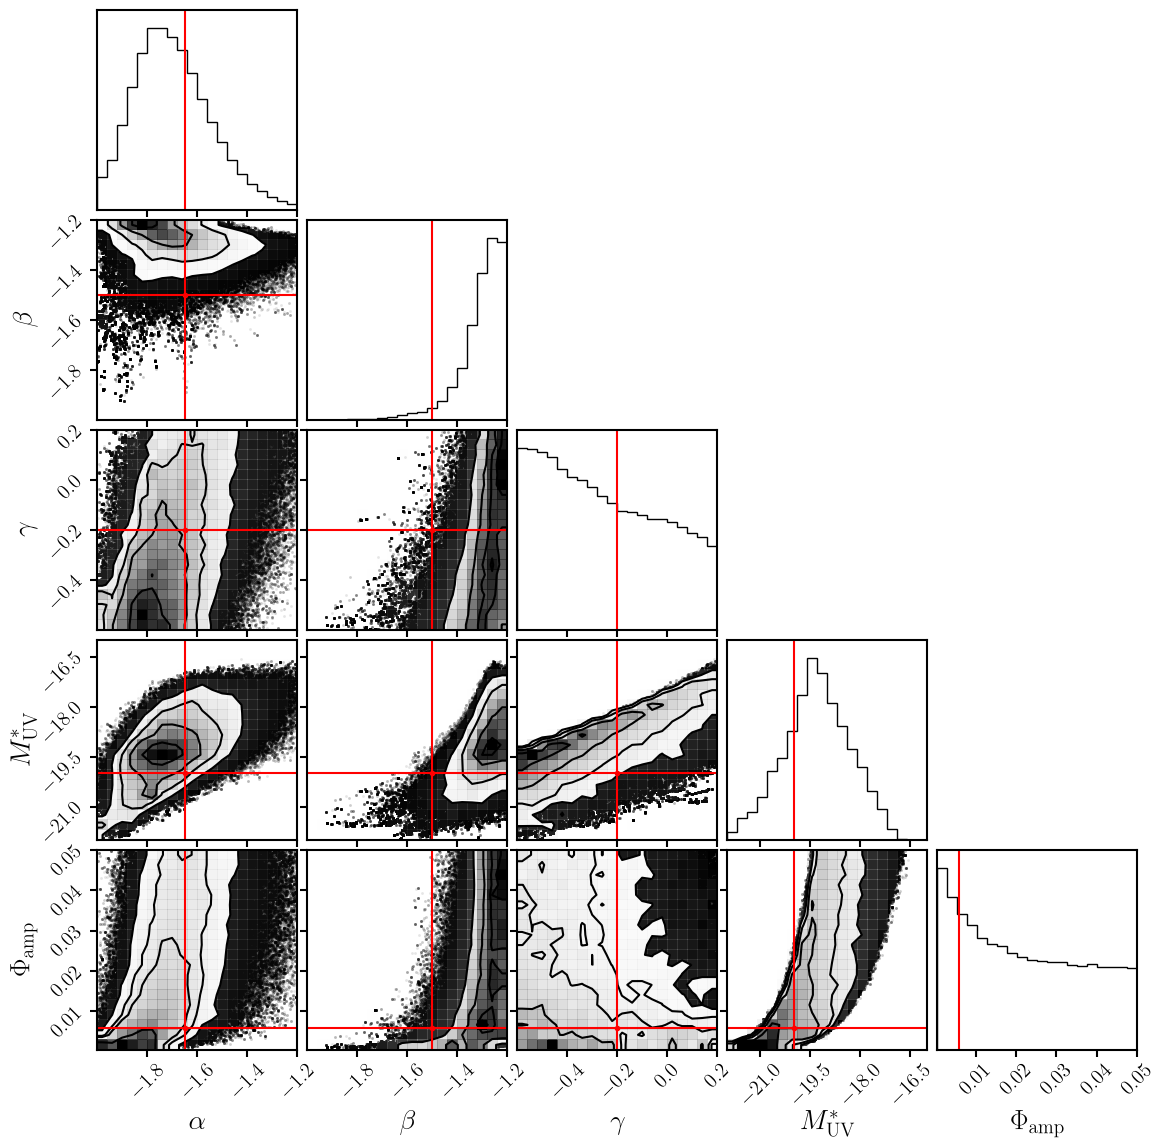

In [26]:
fig = DFM.corner(sampler_z11.flatchain[20000:,:], 
                 range=prior_bounds, 
                 labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'], label_kwargs={'fontsize': 20})
DFM.overplot_points(fig, [omega_true], color='red')
DFM.overplot_lines(fig, omega_true, color='red')

(2e-05, 0.2)

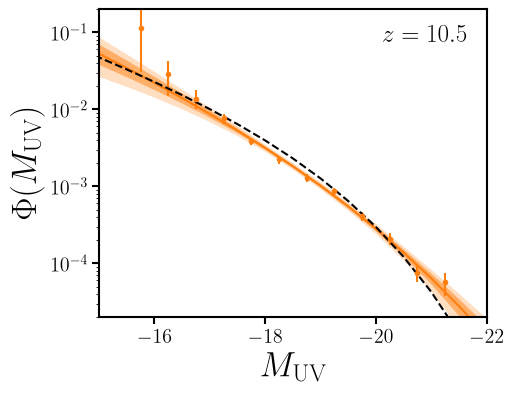

In [27]:
fig = plt.figure(figsize=(5,4))
sub = fig.add_subplot(111)
i = 1
LFs = [] 
for _om in sampler_z11.flatchain[20000:,:]: 
    LFs.append(_om[-1] * UT.LF(Muv_bin, z_meds[i], _om[:-1]))
q00, q0, q1, q2, q22 = np.quantile(np.array(LFs), [0.025, 0.16, 0.5, 0.84, 0.975], axis=0)

sub.fill_between(Muv_bin, q00, q22, edgecolor='none', facecolor='C%i' % i, alpha=0.25)
sub.fill_between(Muv_bin, q0, q2, edgecolor='none', facecolor='C%i' % i, alpha=0.5)
sub.plot(Muv_bin, q1, color='C%i' % i)
sub.errorbar(0.5*(Muv_bin[:-1]+Muv_bin[1:]), uvlf[:,3], yerr=0.5*(uvlf[:,4]+uvlf[:,5]), fmt='.C%i' % i)

sub.plot(Muv_bin, omega_true[-1] * UT.LF(Muv_bin, z_meds[i], omega_true[:-1]), c='k', ls='--')
sub.text(0.95, 0.95, r'$z=%.1f$' % z_meds[i], fontsize=18, transform=sub.transAxes, ha='right', va='top')
sub.set_xlabel(r'$M_{\rm UV}$', fontsize=25)
sub.set_xlim(-15, -22)
sub.set_ylabel(r'$\Phi(M_{\rm UV})$', fontsize=25)
sub.set_yscale('log') 
sub.set_ylim(2e-5, 2e-1)

In [28]:
z9_bins = (uvlf[:,0] > 0)
def log_posterior_z9(omega, silent=True):
    lp = log_prior(omega) # prior 
    if not np.isfinite(lp): return -np.inf
        
    # LF double power law
    lf_model = omega[-1] * UT.LF(0.5*(Muv_bin[:-1]+Muv_bin[1:]), z_meds[0], omega[:-1])
    # chi2
    chi2 = np.sum(((lf_model - uvlf[:,0])**2 / (0.5 * (uvlf[:,1]+uvlf[:,2]))**2)[z9_bins])
    return -0.5*chi2

In [29]:
ndim, nwalkers = 5, 20
p0 = np.array([
    np.random.uniform(prior_bounds[0][0], prior_bounds[0][1], nwalkers),
    np.random.uniform(prior_bounds[1][0], prior_bounds[1][1], nwalkers),
    np.random.uniform(prior_bounds[2][0], prior_bounds[2][1], nwalkers),
    np.random.uniform(prior_bounds[3][0], prior_bounds[3][1], nwalkers),
    np.random.uniform(prior_bounds[4][0], prior_bounds[4][1], nwalkers),
]).T

sampler_z9 = emcee.EnsembleSampler(nwalkers, ndim, log_posterior_z9)
_ = sampler_z9.run_mcmc(p0, 50000, progress=True)

/var/folders/y3/8t3m3rcs365c62spx46f98vm0000gq/T/ipykernel_16718/3804912788.py:9: RuntimeWarning: divide by zero encountered in divide
  chi2 = np.sum(((lf_model - uvlf[:,0])**2 / (0.5 * (uvlf[:,1]+uvlf[:,2]))**2)[z9_bins])
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50000/50000 [00:13<00:00, 3780.86it/s]


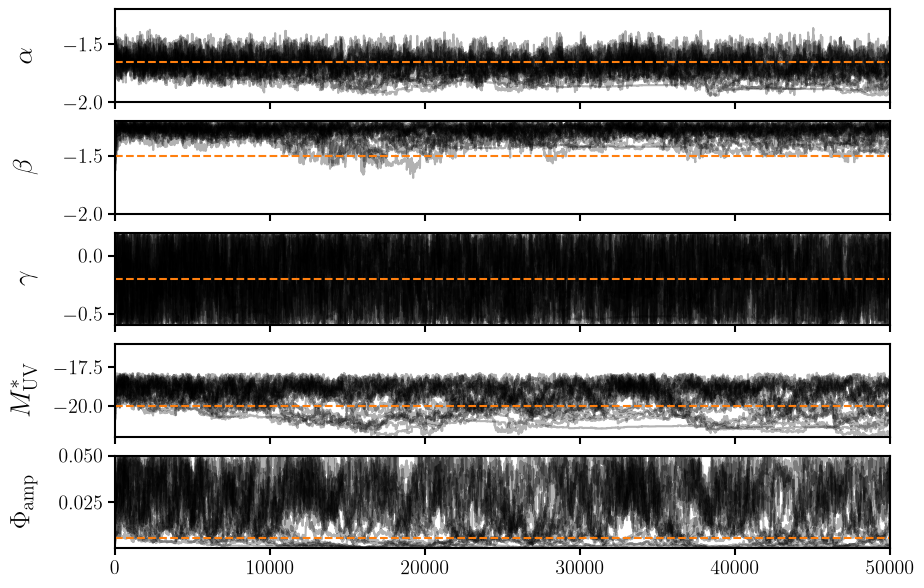

In [30]:
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
samples = sampler_z9.get_chain()
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.plot([0, samples.shape[0]], [omega_true[i], omega_true[i]], c='C1', ls='--')
    ax.set_xlim(0, len(samples))
    ax.set_ylabel([r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'][i], fontsize=20)
    ax.yaxis.set_label_coords(-0.1, 0.5)
    ax.set_ylim(prior_bounds[i])

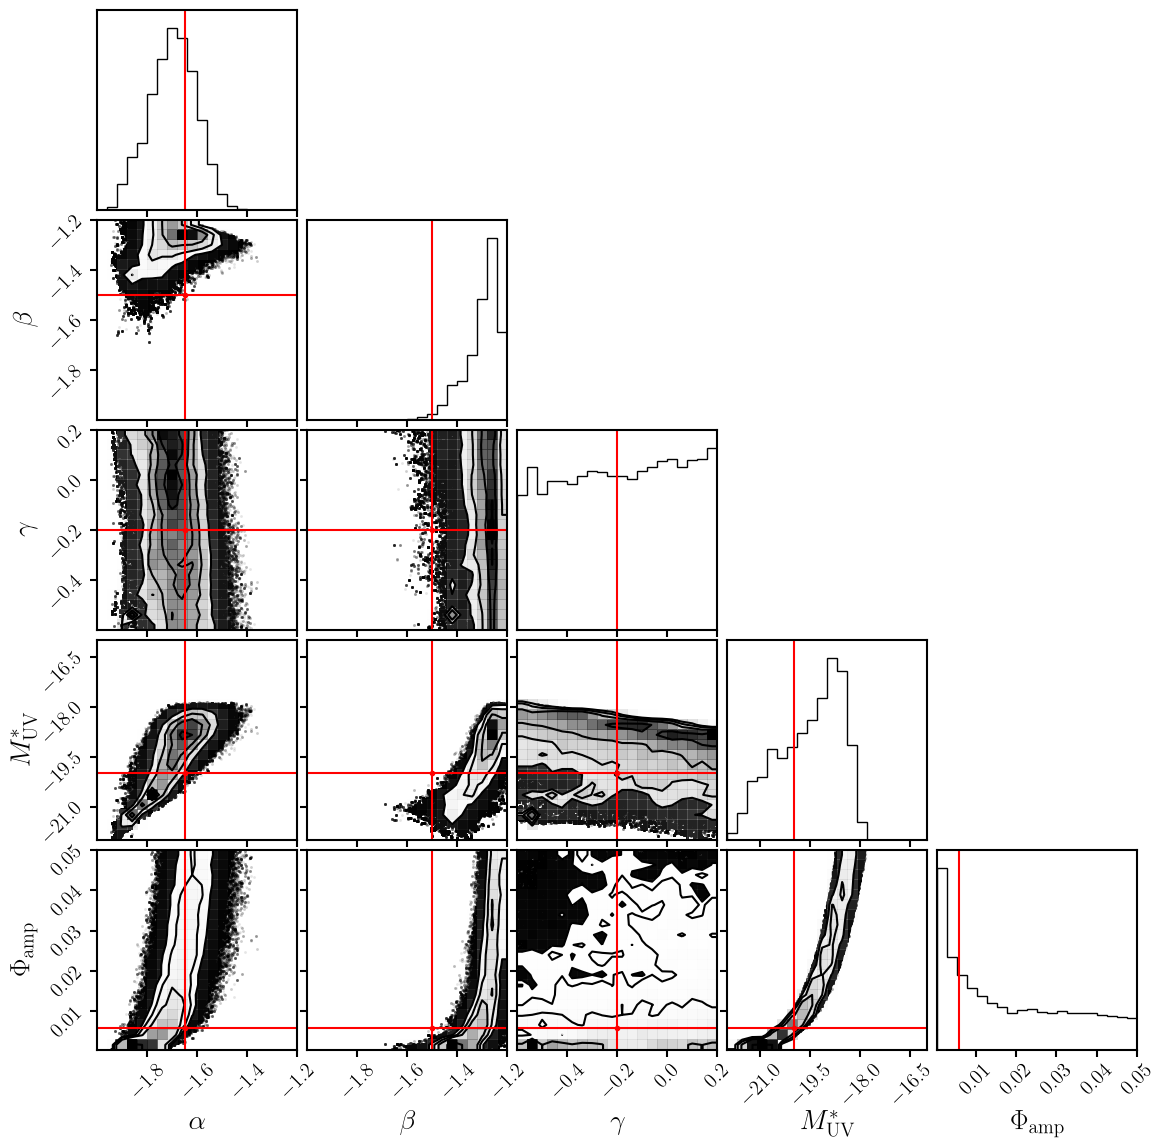

In [31]:
fig = DFM.corner(sampler_z9.flatchain[20000:,:], 
                 range=prior_bounds, 
                 labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'], label_kwargs={'fontsize': 20})
DFM.overplot_points(fig, [omega_true], color='red')
DFM.overplot_lines(fig, omega_true, color='red')

(2e-05, 0.2)

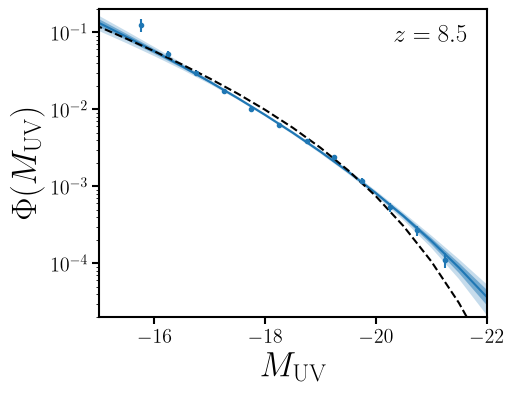

In [32]:
fig = plt.figure(figsize=(5,4))
sub = fig.add_subplot(111)
i = 0
LFs = [] 
for _om in sampler_z9.flatchain[20000:,:]: 
    LFs.append(_om[-1] * UT.LF(Muv_bin, z_meds[i], _om[:-1]))
q00, q0, q1, q2, q22 = np.quantile(np.array(LFs), [0.025, 0.16, 0.5, 0.84, 0.975], axis=0)

sub.fill_between(Muv_bin, q00, q22, edgecolor='none', facecolor='C%i' % i, alpha=0.25)
sub.fill_between(Muv_bin, q0, q2, edgecolor='none', facecolor='C%i' % i, alpha=0.5)
sub.plot(Muv_bin, q1, color='C%i' % i)
sub.errorbar(0.5*(Muv_bin[:-1]+Muv_bin[1:]), uvlf[:,0], yerr=0.5*(uvlf[:,1]+uvlf[:,2]), fmt='.C%i' % i)

sub.plot(Muv_bin, omega_true[-1] * UT.LF(Muv_bin, z_meds[i], omega_true[:-1]), c='k', ls='--')
sub.text(0.95, 0.95, r'$z=%.1f$' % z_meds[i], fontsize=18, transform=sub.transAxes, ha='right', va='top')
sub.set_xlabel(r'$M_{\rm UV}$', fontsize=25)
sub.set_xlim(-15, -22)
sub.set_ylabel(r'$\Phi(M_{\rm UV})$', fontsize=25)
sub.set_yscale('log') 
sub.set_ylim(2e-5, 2e-1)

In [33]:
with open('/Users/ch54662/data/px2cosmo/mock/benchmark/mcmc_benchmark_z14.pkl', 'wb') as f:
    pickle.dump(sampler_z14, f)
with open('/Users/ch54662/data/px2cosmo/mock/benchmark/mcmc_benchmark_z11.pkl', 'wb') as f:
    pickle.dump(sampler_z11, f)
with open('/Users/ch54662/data/px2cosmo/mock/benchmark/mcmc_benchmark_z9.pkl', 'wb') as f:
    pickle.dump(sampler_z9, f)    

In [34]:
np.save('/Users/ch54662/data/px2cosmo/mock/benchmark/mcmc_benchmark_z14.npy', sampler_z14.flatchain[20000:,:])
np.save('/Users/ch54662/data/px2cosmo/mock/benchmark/mcmc_benchmark_z11.npy', sampler_z11.flatchain[20000:,:])
np.save('/Users/ch54662/data/px2cosmo/mock/benchmark/mcmc_benchmark_z9.npy', sampler_z9.flatchain[20000:,:])

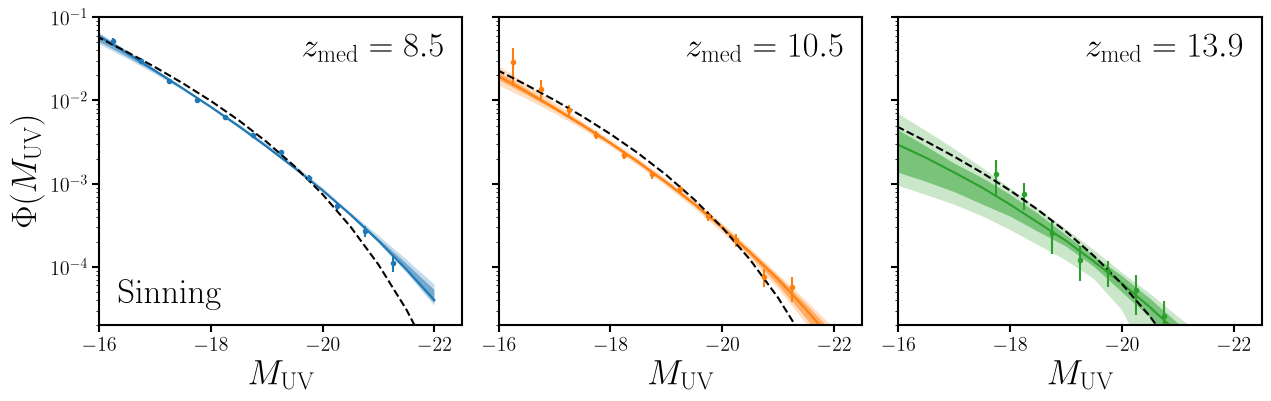

In [35]:
fig = plt.figure(figsize=(15,4))
for i, z in enumerate(z_meds): 
    sub = fig.add_subplot(1,3,i+1)

    _sampler = [sampler_z9, sampler_z11, sampler_z14][i]

    LFs = []
    for _om in _sampler.flatchain[-5000:,:][::10]: 
        LFs.append(_om[-1] * UT.LF(Muv_bin, z, _om[:-1]))
    q00, q0, q1, q2, q22 = np.quantile(np.array(LFs), [0.025, 0.16, 0.5, 0.84, 0.975], axis=0)

    sub.fill_between(Muv_bin, q00, q22, edgecolor='none', facecolor='C%i' % i, alpha=0.25)
    sub.fill_between(Muv_bin, q0, q2, edgecolor='none', facecolor='C%i' % i, alpha=0.5)
    sub.plot(Muv_bin, q1, color='C%i' % i)
    sub.errorbar(0.5*(Muv_bin[:-1]+Muv_bin[1:]), uvlf[:,i*3], yerr=0.5*(uvlf[:,i*3+1]+uvlf[:,i*3+2]), fmt='.C%i' % i)

    sub.plot(Muv_bin, omega_true[-1] * UT.LF(Muv_bin, z, omega_true[:-1]), c='k', ls='--')

    sub.text(0.95, 0.95, r'$z_{\rm med}=%.1f$' % z, fontsize=25, transform=sub.transAxes, ha='right', va='top')
    if i == 0: sub.text(0.05, 0.05, r'Sinning', fontsize=25, transform=sub.transAxes, ha='left', va='bottom')
    sub.set_xlabel(r'$M_{\rm UV}$', fontsize=25)
    sub.set_xlim(-16, -22.5)
    if i == 0: sub.set_ylabel(r'$\Phi(M_{\rm UV})$', fontsize=25)
    else: sub.tick_params(labelleft=False)
    sub.set_yscale('log') 
    sub.set_ylim(2e-5, 1e-1)

fig.subplots_adjust(wspace=0.1)
fig.savefig('benchmark_uvlf.pdf')